In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [29]:
g = 9.81   # gravitational acceleration (m/s^2)
L = 1.0    # length of pendulum (m)

In [30]:
# --- 2. EQUATION OF MOTION ---
# d^2θ/dt^2 = -(g/L) sin(θ)

def pendulum_ode(t, y):
    theta = y[0]   # angular position
    omega = y[1]   # angular velocity
    
    dtheta_dt = omega
    domega_dt = -(g / L) * np.sin(theta)
    
    return [dtheta_dt, domega_dt]

In [31]:
def compute_period(theta0):
    y0 = [theta0, 0]
    sol = solve_ivp(pendulum_ode, (t_start, t_end), y0, t_eval=t_eval)

    theta = sol.y[0]
    t = sol.t

    # Find zero crossings
    crossings = np.where(np.diff(np.sign(theta)))[0]

    if len(crossings) > 1:
        T = 2 * (t[crossings[1]] - t[crossings[0]])
        return T
    else:
        return None

In [32]:
# --- 3. TIME GRID ---
import numpy as np  

t_start = 0
t_end = 20
t_points = 3000

t_eval = np.linspace(t_start, t_end, t_points)

In [33]:
angles_deg = np.linspace(1, 90, 30)
angles_rad = np.radians(angles_deg)

def pendulum_ode(t, y):
    theta, omega = y
    return [omega, -(g / L) * np.sin(theta)]

In [34]:
L = 1.0   
g = 9.81
angles_deg = [10, 20, 30]  
T_theory = 2 * np.pi * np.sqrt(L / g)
T_theory_list = [T_theory] * len(angles_deg)

In [35]:
periods = []

for theta0 in angles_rad:
    T = compute_period(theta0)
    periods.append(T)

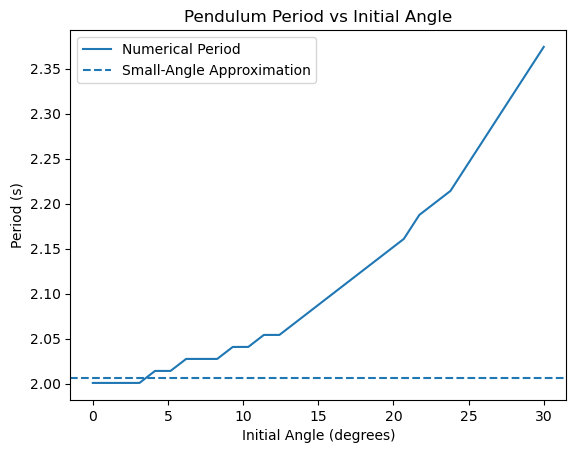

In [39]:
import matplotlib.pyplot as plt
import numpy as np

T0 = 2 * np.pi * np.sqrt(L / g)

# FIX: force angles to match periods length
angles_deg = np.linspace(0, 30, len(periods))

plt.figure()
plt.plot(angles_deg, periods, label="Numerical Period")
plt.axhline(T0, linestyle='--', label="Small-Angle Approximation")

plt.xlabel("Initial Angle (degrees)")
plt.ylabel("Period (s)")
plt.title("Pendulum Period vs Initial Angle")
plt.legend()
plt.show()